# Optimización para portafolios de inversion

In [1]:
from qiskit.circuit.library import TwoLocal
from qiskit.result import QuasiDistribution
from qiskit_aer.primitives import Sampler
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_finance.data_providers import YahooDataProvider
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_finance.exceptions import QiskitFinanceError
from qiskit_optimization.translators import from_docplex_mp
from docplex.mp.model import Model

import numpy as np
import matplotlib.pyplot as plt
import datetime
import yfinance as yf

In [2]:
#Se define una funcion para visualizar mejor los resultados 
def print_result(result):

    print(
        f"Optimal: selection {result.x}, "
        f"value {result.fval:.4f}"
    )

    print("\n----------------- Full result ---------------------")
    print("selection\t\tvalue\t\tprobability")
    print("---------------------------------------------------")

    for sample in result.samples:

        x = sample.x
        value = sample.fval
        prob = sample.probability

        print(
            f"{x}\t"
            f"{value:.4f}\t\t"
            f"{prob:.4f}"
        )

### Obtención de datos para el vector de rendimientos 

[*********************100%***********************]  9 of 9 completed


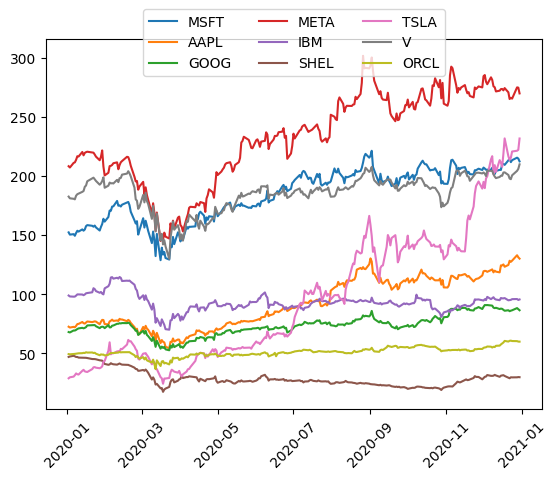

In [3]:
tickers = ["MSFT", "AAPL", "GOOG", "META", "IBM", "SHEL", "TSLA", "V", "ORCL"]

raw = yf.download(
    tickers,
    start="2020-01-01",
    end="2020-12-31",
    auto_adjust=False
)

prices = raw["Adj Close"]

for ticker in tickers:
    plt.plot(prices[ticker], label=ticker)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=3)
plt.xticks(rotation=45)
plt.show()

In [4]:
returns = prices.pct_change().dropna()

mu = returns.mean().to_numpy()

sigma = returns.cov().to_numpy()

print("Vector de rendimientos esperados:")
print(mu)
#print(sigma)

Vector de rendimientos esperados:
[ 0.00276907  0.00125223  0.00019794  0.00145423  0.00171069  0.00109563
 -0.00100434  0.0099507   0.00091723]


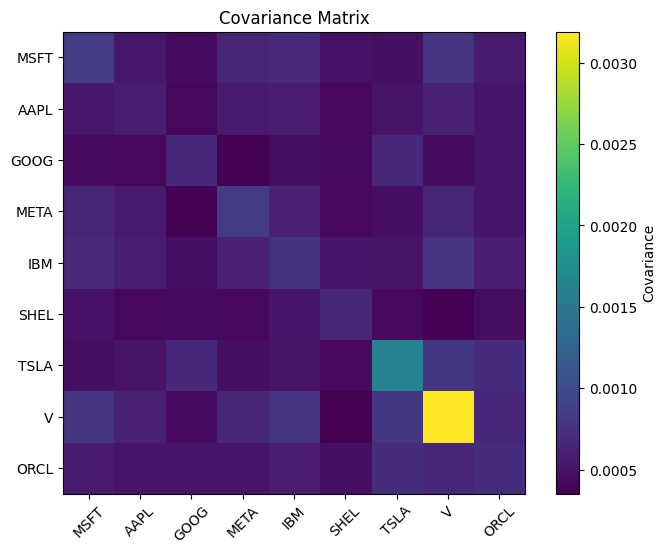

In [5]:
plt.figure(figsize=(8, 6))
plt.imshow(sigma, interpolation="nearest")
plt.colorbar(label="Covariance")

plt.xticks(range(len(tickers)), tickers, rotation=45)
plt.yticks(range(len(tickers)), tickers)

plt.title("Covariance Matrix")
plt.show()

### Crear el problema de optimización de cartera

In [6]:
q = 0.5
budget = 2
#penalty = num_assets

portfolio = PortfolioOptimization(
    expected_returns=mu,
    covariances=sigma,
    risk_factor=q,
    budget=2
)

# Convert to quadratic program (QUBO)
qp = portfolio.to_quadratic_program()

# Print optimization problem
print(qp.prettyprint())

Problem name: Portfolio optimization

Minimize
  0.0004342171494410906*x_0^2 + 0.000536571312262184*x_0*x_1
  + 0.0004388178009929517*x_0*x_2 + 0.000655895121379659*x_0*x_3
  + 0.0006861890270598863*x_0*x_4 + 0.0004894003923783677*x_0*x_5
  + 0.0004726704239345383*x_0*x_6 + 0.0007862369254631115*x_0*x_7
  + 0.00056302443175738*x_0*x_8 + 0.0002927136514161749*x_1^2
  + 0.0004108000668607774*x_1*x_2 + 0.0005634007884971182*x_1*x_3
  + 0.0005720634123161122*x_1*x_4 + 0.00041428554843301045*x_1*x_5
  + 0.0005038893630331628*x_1*x_6 + 0.0006122466016379642*x_1*x_7
  + 0.0005143100434591415*x_1*x_8 + 0.00033346458374160334*x_2^2
  + 0.00037485881799330704*x_2*x_3 + 0.00045858441593396506*x_2*x_4
  + 0.0004412175808257328*x_2*x_5 + 0.0006831406597229679*x_2*x_6
  + 0.000440855522447445*x_2*x_7 + 0.0005130128621393919*x_2*x_8
  + 0.00042045683296717526*x_3^2 + 0.0006137764484676633*x_3*x_4
  + 0.000428915672550686*x_3*x_5 + 0.0004674244861711638*x_3*x_6
  + 0.0006592637601204814*x_3*x_7 + 0.00

### Classical solution

In [9]:
from qiskit_algorithms import NumPyMinimumEigensolver

exact = MinimumEigenOptimizer(
    NumPyMinimumEigensolver()
)

exact_result = exact.solve(qp)
print("Done")
#rint(exact_result)
#print_result(exact_result)

Done


### QAOA

In [17]:
from qiskit_aer.primitives import Sampler
shots = 1024

mes = QAOA(
    sampler=StatevectorSampler(),
    optimizer=COBYLA(),
    reps=1
)

meo = MinimumEigenOptimizer(min_eigen_solver=mes)

result = meo.solve(qp)

print("Done")
#print_result(result)

/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Done


In [14]:
exact_solver = MinimumEigenOptimizer(NumPyMinimumEigensolver())
exact_result = exact_solver.solve(qp)

print("Exact result:")
print_result(exact_result)

print("QAOA result:")
print_result(result)

Exact result:
Optimal: selection [1. 0. 0. 0. 0. 0. 0. 1. 0.], value -0.0099

----------------- Full result ---------------------
selection		value		probability
---------------------------------------------------
[1. 0. 0. 0. 0. 0. 0. 1. 0.]	-0.0099		1.0000
QAOA result:
Optimal: selection [1. 0. 0. 0. 0. 0. 0. 1. 0.], value -0.0099

----------------- Full result ---------------------
selection		value		probability
---------------------------------------------------
[1. 0. 0. 0. 0. 0. 0. 1. 0.]	-0.0099		0.0000
[0. 0. 0. 0. 1. 0. 0. 1. 0.]	-0.0089		0.0000
[0. 0. 0. 1. 0. 0. 0. 1. 0.]	-0.0087		0.0000
[0. 1. 0. 0. 0. 0. 0. 1. 0.]	-0.0087		0.0000
[0. 0. 0. 0. 0. 0. 0. 1. 1.]	-0.0082		0.0000
[0. 0. 1. 0. 0. 0. 0. 1. 0.]	-0.0078		0.0000
[0. 0. 0. 0. 0. 0. 1. 1. 0.]	-0.0057		0.0000
[1. 1. 0. 0. 0. 0. 0. 0. 0.]	-0.0028		0.0000
[1. 0. 0. 1. 0. 0. 0. 0. 0.]	-0.0027		0.0000
[1. 0. 0. 0. 0. 1. 0. 0. 0.]	-0.0026		0.0000
[1. 0. 0. 0. 0. 0. 0. 0. 1.]	-0.0023		0.0001
[1. 0. 1. 0. 0. 0. 0. 0. 0.]	-0.0018	

In [15]:
print("Exact value:", exact_result.fval)
print("QAOA value:", result.fval)
print("Difference:", result.fval - exact_result.fval)

Exact value: -0.00990507885600146
QAOA value: -0.00990507885600146
Difference: 0.0


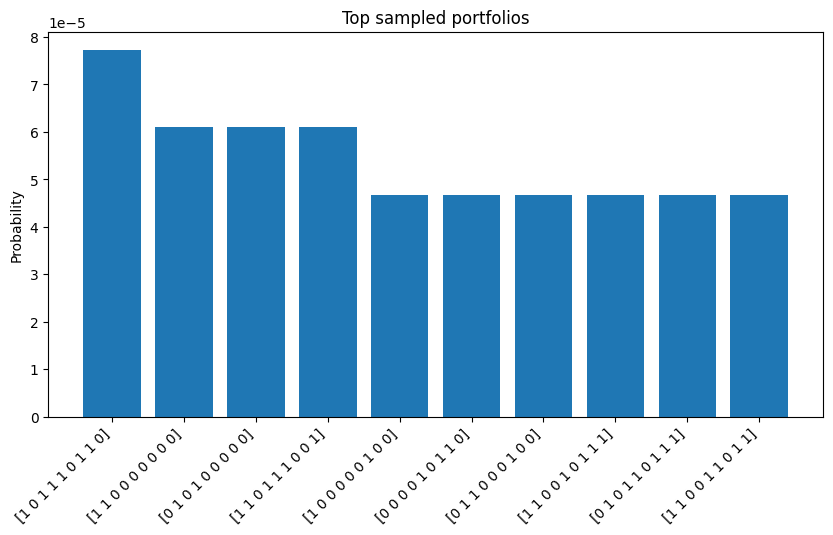

In [34]:
def plot_sample_probabilities(result, top_k=10):
    samples = sorted(result.samples, key=lambda s: s.probability, reverse=True)

    labels = [str(s.x.astype(int)) for s in samples[:top_k]]
    probs = [s.probability for s in samples[:top_k]]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, probs)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Probability")
    plt.title("Top sampled portfolios")
    plt.show()

plot_sample_probabilities(result)

Compare different QAOA depths

In [30]:
for p in [1, 2, 3, 4]:
    qaoa = QAOA(
        sampler=StatevectorSampler(),
        optimizer=COBYLA(maxiter=200),
        reps=p
    )

    optimizer = MinimumEigenOptimizer(qaoa)
    result_p = optimizer.solve(qp)

    print(f"\nQAOA reps = {p}")
    print_result(result_p)

/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



QAOA reps = 1
Optimal: selection [1. 0. 0. 0. 0. 0. 1. 0. 0.], value -0.0099

----------------- Full result ---------------------
selection		value		probability
---------------------------------------------------
[1. 0. 0. 0. 0. 0. 1. 0. 0.]	-0.0099		0.0000
[0. 0. 0. 0. 0. 1. 1. 0. 0.]	-0.0089		0.0000
[0. 0. 0. 0. 1. 0. 1. 0. 0.]	-0.0087		0.0000
[0. 1. 0. 0. 0. 0. 1. 0. 0.]	-0.0087		0.0000
[0. 0. 0. 0. 0. 0. 1. 1. 0.]	-0.0085		0.0000
[0. 0. 0. 0. 0. 0. 1. 0. 1.]	-0.0082		0.0000
[0. 0. 1. 0. 0. 0. 1. 0. 0.]	-0.0081		0.0000
[0. 0. 0. 1. 0. 0. 1. 0. 0.]	-0.0078		0.0000
[1. 0. 0. 0. 0. 1. 0. 0. 0.]	-0.0030		0.0000
[1. 1. 0. 0. 0. 0. 0. 0. 0.]	-0.0028		0.0000
[1. 0. 0. 0. 1. 0. 0. 0. 0.]	-0.0027		0.0000
[1. 0. 0. 0. 0. 0. 0. 1. 0.]	-0.0025		0.0000
[1. 0. 0. 0. 0. 0. 0. 0. 1.]	-0.0023		0.0000
[1. 0. 1. 0. 0. 0. 0. 0. 0.]	-0.0022		0.0000
[1. 0. 0. 1. 0. 0. 0. 0. 0.]	-0.0018		0.0000
[0. 0. 0. 0. 1. 1. 0. 0. 0.]	-0.0017		0.0000
[0. 1. 0. 0. 0. 1. 0. 0. 0.]	-0.0017		0.0000
[0. 0. 0. 0. 0. 1. 0. 

/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



QAOA reps = 2
Optimal: selection [1. 0. 0. 0. 0. 0. 1. 0. 0.], value -0.0099

----------------- Full result ---------------------
selection		value		probability
---------------------------------------------------
[1. 0. 0. 0. 0. 0. 1. 0. 0.]	-0.0099		0.0000
[0. 0. 0. 0. 0. 1. 1. 0. 0.]	-0.0089		0.0000
[0. 0. 0. 0. 0. 0. 1. 1. 0.]	-0.0085		0.0000
[0. 0. 0. 0. 0. 0. 1. 0. 1.]	-0.0082		0.0000
[0. 0. 1. 0. 0. 0. 1. 0. 0.]	-0.0081		0.0000
[0. 0. 0. 1. 0. 0. 1. 0. 0.]	-0.0078		0.0000
[1. 0. 0. 0. 0. 1. 0. 0. 0.]	-0.0030		0.0000
[1. 1. 0. 0. 0. 0. 0. 0. 0.]	-0.0028		0.0000
[1. 0. 0. 0. 0. 0. 0. 0. 1.]	-0.0023		0.0000
[1. 0. 1. 0. 0. 0. 0. 0. 0.]	-0.0022		0.0000
[1. 0. 0. 1. 0. 0. 0. 0. 0.]	-0.0018		0.0000
[0. 1. 0. 0. 0. 1. 0. 0. 0.]	-0.0017		0.0000
[0. 0. 0. 0. 0. 1. 0. 1. 0.]	-0.0015		0.0000
[0. 1. 0. 0. 1. 0. 0. 0. 0.]	-0.0014		0.0000
[0. 0. 0. 0. 0. 1. 0. 0. 1.]	-0.0013		0.0000
[0. 0. 1. 0. 0. 1. 0. 0. 0.]	-0.0012		0.0000
[0. 1. 0. 0. 0. 0. 0. 1. 0.]	-0.0012		0.0000
[0. 0. 1. 0. 1. 0. 0. 

/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



QAOA reps = 3
Optimal: selection [1. 0. 0. 0. 0. 0. 1. 0. 0.], value -0.0099

----------------- Full result ---------------------
selection		value		probability
---------------------------------------------------
[1. 0. 0. 0. 0. 0. 1. 0. 0.]	-0.0099		0.0001
[0. 0. 0. 0. 0. 1. 1. 0. 0.]	-0.0089		0.0000
[0. 0. 0. 0. 1. 0. 1. 0. 0.]	-0.0087		0.0000
[0. 1. 0. 0. 0. 0. 1. 0. 0.]	-0.0087		0.0001
[0. 0. 0. 0. 0. 0. 1. 1. 0.]	-0.0085		0.0002
[0. 0. 0. 0. 0. 0. 1. 0. 1.]	-0.0082		0.0002
[0. 0. 1. 0. 0. 0. 1. 0. 0.]	-0.0081		0.0000
[0. 0. 0. 1. 0. 0. 1. 0. 0.]	-0.0078		0.0000
[1. 0. 0. 0. 0. 1. 0. 0. 0.]	-0.0030		0.0000
[1. 1. 0. 0. 0. 0. 0. 0. 0.]	-0.0028		0.0000
[1. 0. 0. 0. 1. 0. 0. 0. 0.]	-0.0027		0.0000
[1. 0. 0. 0. 0. 0. 0. 1. 0.]	-0.0025		0.0001
[1. 0. 0. 0. 0. 0. 0. 0. 1.]	-0.0023		0.0000
[1. 0. 1. 0. 0. 0. 0. 0. 0.]	-0.0022		0.0001
[1. 0. 0. 1. 0. 0. 0. 0. 0.]	-0.0018		0.0000
[0. 0. 0. 0. 1. 1. 0. 0. 0.]	-0.0017		0.0001
[0. 1. 0. 0. 0. 1. 0. 0. 0.]	-0.0017		0.0002
[0. 0. 0. 0. 0. 1. 0. 

/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



QAOA reps = 4
Optimal: selection [0. 0. 0. 0. 0. 1. 1. 0. 0.], value -0.0089

----------------- Full result ---------------------
selection		value		probability
---------------------------------------------------
[0. 0. 0. 0. 0. 1. 1. 0. 0.]	-0.0089		0.0000
[1. 0. 0. 1. 0. 0. 0. 0. 0.]	-0.0018		0.0000
[0. 0. 0. 0. 1. 0. 0. 1. 0.]	-0.0012		0.0000
[0. 1. 1. 0. 0. 0. 0. 0. 0.]	-0.0009		0.0000
[0. 0. 1. 1. 0. 0. 0. 0. 0.]	0.0003		0.0000
[1. 0. 0. 0. 0. 1. 1. 0. 0.]	-0.0098		0.0000
[1. 0. 0. 0. 0. 0. 1. 1. 0.]	-0.0095		0.0000
[1. 0. 0. 0. 0. 0. 1. 0. 1.]	-0.0092		0.0000
[1. 0. 1. 0. 0. 0. 1. 0. 0.]	-0.0091		0.0000
[1. 0. 0. 1. 0. 0. 1. 0. 0.]	-0.0089		0.0000
[0. 0. 0. 0. 1. 1. 1. 0. 0.]	-0.0087		0.0000
[0. 1. 0. 0. 1. 0. 1. 0. 0.]	-0.0085		0.0000
[0. 0. 0. 0. 0. 1. 1. 1. 0.]	-0.0085		0.0000
[0. 0. 0. 0. 0. 0. 1. 0. 0.]	-0.0084		0.0015
[0. 0. 0. 0. 0. 1. 1. 0. 1.]	-0.0082		0.0000
[0. 1. 0. 0. 0. 0. 1. 0. 1.]	-0.0081		0.0000
[0. 0. 1. 0. 0. 1. 1. 0. 0.]	-0.0081		0.0000
[1. 0. 0. 1. 0. 0. 1. 1